#Behavioral Visualizations

####What we'll visualize today:

-Blink timeline per user

-Gaze movement paths

-Pupil movement graphs

-Combined behavioral analysis charts

In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE         = "/content/drive/MyDrive/EyeMotionID"
MRL_PATH     = os.path.join(BASE, "data/raw/MRL_Eye/data")
MPI_PATH     = os.path.join(BASE, "data/raw/MPIIGAZE/MPIIGaze/Data/Original")
OPENEDS_PATH = os.path.join(BASE, "data/raw/openeds/openEDS/openEDS")
PLOTS        = os.path.join(BASE, "results/plots")
os.makedirs(PLOTS, exist_ok=True)

print("✓ Drive mounted")
print("MRL exists    :", os.path.exists(MRL_PATH))
print("MPII exists   :", os.path.exists(MPI_PATH))
print("OpenEDS exists:", os.path.exists(OPENEDS_PATH))

Mounted at /content/drive
✓ Drive mounted
MRL exists    : True
MPII exists   : True
OpenEDS exists: True


###Blink timeline — multi-user comparison

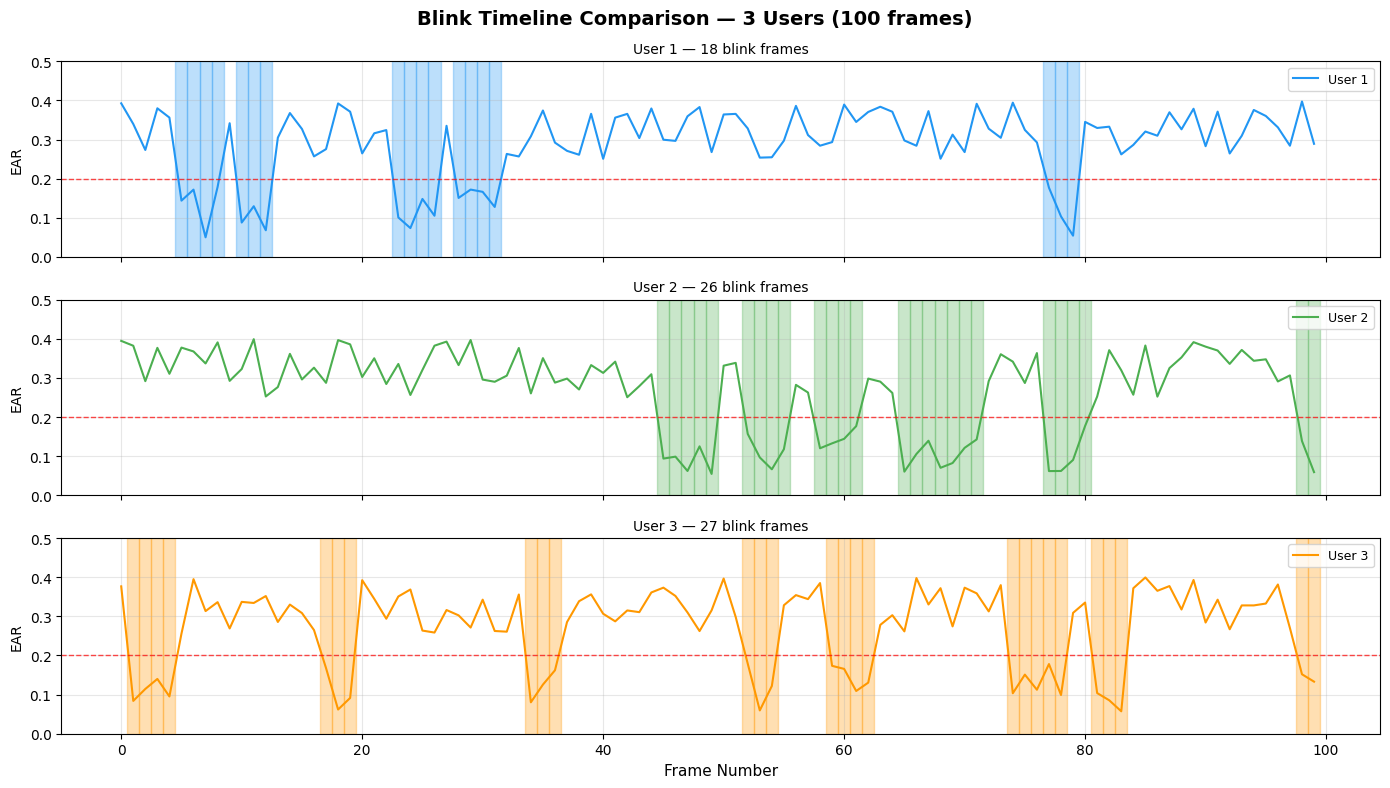

✓ Saved → results/plots/behavioral_blink_timeline.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
FRAMES = 100
USERS  = ["User 1", "User 2", "User 3"]
COLORS = ["#2196F3", "#4CAF50", "#FF9800"]

# simulate different blink rates per user
blink_rates = [0.04, 0.07, 0.10]  # 4%, 7%, 10% blink probability

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Blink Timeline Comparison — 3 Users (100 frames)",
             fontsize=14, fontweight='bold')

all_ear_values = []
for idx, (user, rate, color) in enumerate(zip(USERS, blink_rates, COLORS)):
    ear_values = []
    i = 0
    while i < FRAMES:
        if np.random.random() < rate:
            blink_len = np.random.randint(3, 6)
            for b in range(blink_len):
                if i + b < FRAMES:
                    ear_values.append(np.random.uniform(0.05, 0.18))
            i += blink_len
        else:
            ear_values.append(np.random.uniform(0.25, 0.40))
            i += 1
    ear_values = ear_values[:FRAMES]
    all_ear_values.append(ear_values)

    axes[idx].plot(ear_values, color=color, linewidth=1.5, label=user)
    axes[idx].axhline(y=0.20, color='red', linestyle='--', linewidth=1, alpha=0.7)
    for i, ear in enumerate(ear_values):
        if ear < 0.20:
            axes[idx].axvspan(i-0.5, i+0.5, alpha=0.3, color=color)
    blink_count = sum(1 for e in ear_values if e < 0.20)
    axes[idx].set_ylabel("EAR", fontsize=10)
    axes[idx].set_title(f"{user} — {blink_count} blink frames", fontsize=10)
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].set_ylim(0, 0.5)
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel("Frame Number", fontsize=11)
plt.tight_layout()
plt.savefig(f"{PLOTS}/behavioral_blink_timeline.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/behavioral_blink_timeline.png")

###Blink frequency comparison bar chart

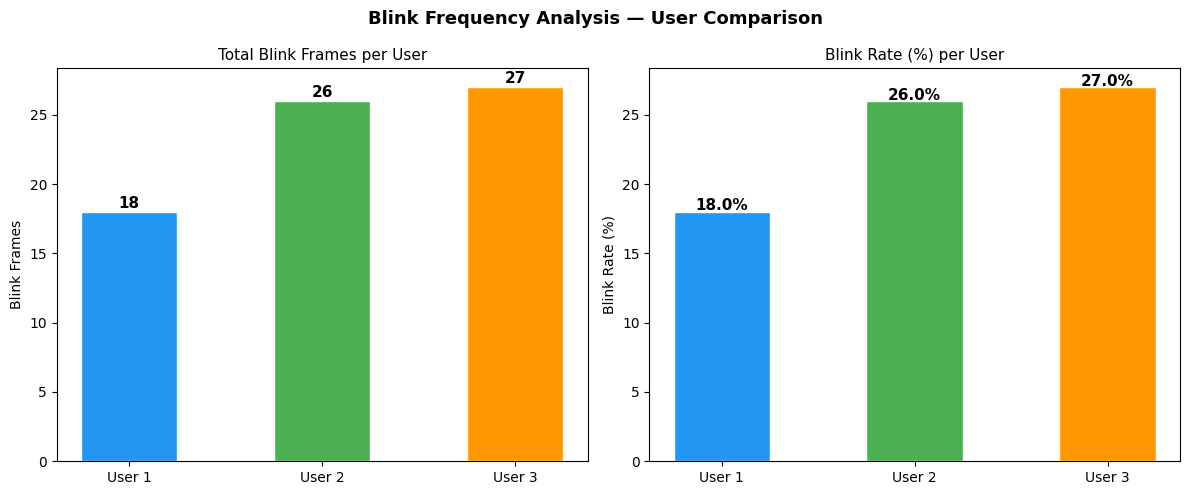

✓ Saved → results/plots/behavioral_blink_frequency.png


In [3]:
blink_counts = [sum(1 for e in ear_vals if e < 0.20)
                for ear_vals in all_ear_values]
blink_rates_actual = [count/FRAMES*100 for count in blink_counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Blink Frequency Analysis — User Comparison",
             fontsize=13, fontweight='bold')

# blink count bar chart
bars = axes[0].bar(USERS, blink_counts, color=COLORS, edgecolor='white', width=0.5)
axes[0].set_title("Total Blink Frames per User", fontsize=11)
axes[0].set_ylabel("Blink Frames")
for bar, count in zip(bars, blink_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(count), ha='center', fontsize=11, fontweight='bold')

# blink rate % chart
bars2 = axes[1].bar(USERS, blink_rates_actual, color=COLORS, edgecolor='white', width=0.5)
axes[1].set_title("Blink Rate (%) per User", fontsize=11)
axes[1].set_ylabel("Blink Rate (%)")
for bar, rate in zip(bars2, blink_rates_actual):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f"{rate:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PLOTS}/behavioral_blink_frequency.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/behavioral_blink_frequency.png")

###Gaze movement paths — multi-user

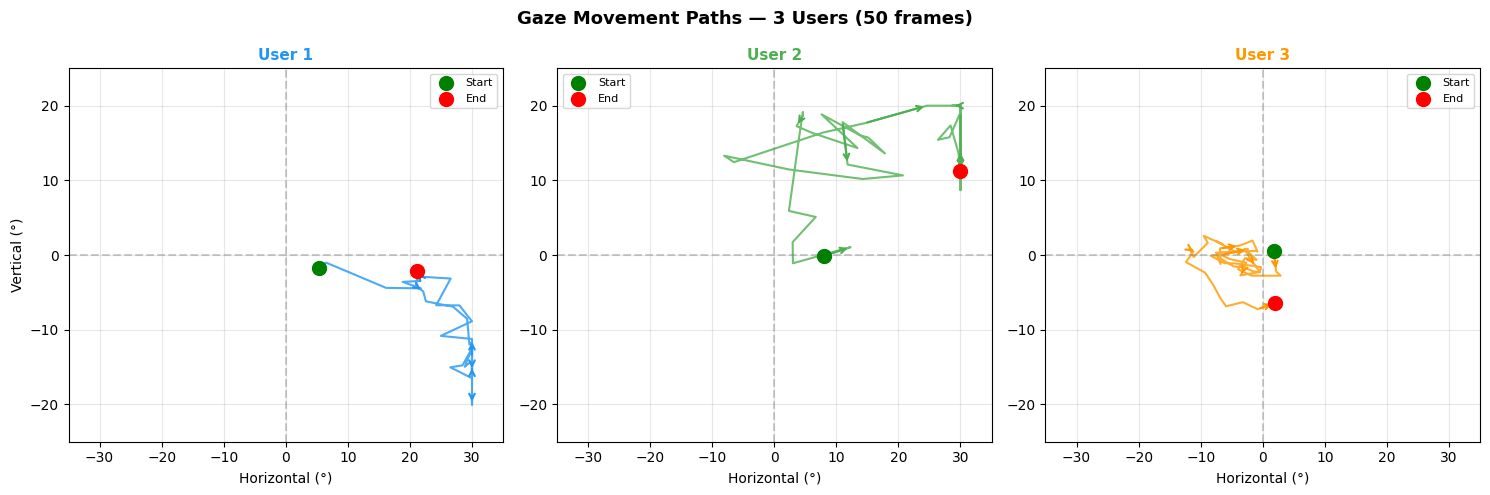

✓ Saved → results/plots/behavioral_gaze_paths.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Gaze Movement Paths — 3 Users (50 frames)",
             fontsize=13, fontweight='bold')

FRAMES_GAZE = 50
gaze_data = []

for idx, (user, color) in enumerate(zip(USERS, COLORS)):
    np.random.seed(idx * 10)
    # each user has different gaze variance
    variance_h = [3, 6, 2][idx]
    variance_v = [2, 4, 1][idx]
    gaze_h = np.clip(np.cumsum(np.random.normal(0, variance_h, FRAMES_GAZE)), -30, 30)
    gaze_v = np.clip(np.cumsum(np.random.normal(0, variance_v, FRAMES_GAZE)), -20, 20)
    gaze_data.append((gaze_h, gaze_v))

    axes[idx].plot(gaze_h, gaze_v, color=color, linewidth=1.5, alpha=0.8)
    axes[idx].scatter(gaze_h[0],  gaze_v[0],  color='green', s=100, zorder=5, label='Start')
    axes[idx].scatter(gaze_h[-1], gaze_v[-1], color='red',   s=100, zorder=5, label='End')
    for i in range(0, FRAMES_GAZE-1, 8):
        axes[idx].annotate('',
            xy=(gaze_h[i+1], gaze_v[i+1]),
            xytext=(gaze_h[i], gaze_v[i]),
            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    axes[idx].set_xlim(-35, 35)
    axes[idx].set_ylim(-25, 25)
    axes[idx].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
    axes[idx].axvline(x=0, color='gray', linestyle='--', alpha=0.4)
    axes[idx].set_title(user, fontsize=11, color=color, fontweight='bold')
    axes[idx].set_xlabel("Horizontal (°)")
    if idx == 0: axes[idx].set_ylabel("Vertical (°)")
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/behavioral_gaze_paths.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/behavioral_gaze_paths.png")

###Pupil movement trajectories — OpenEDS

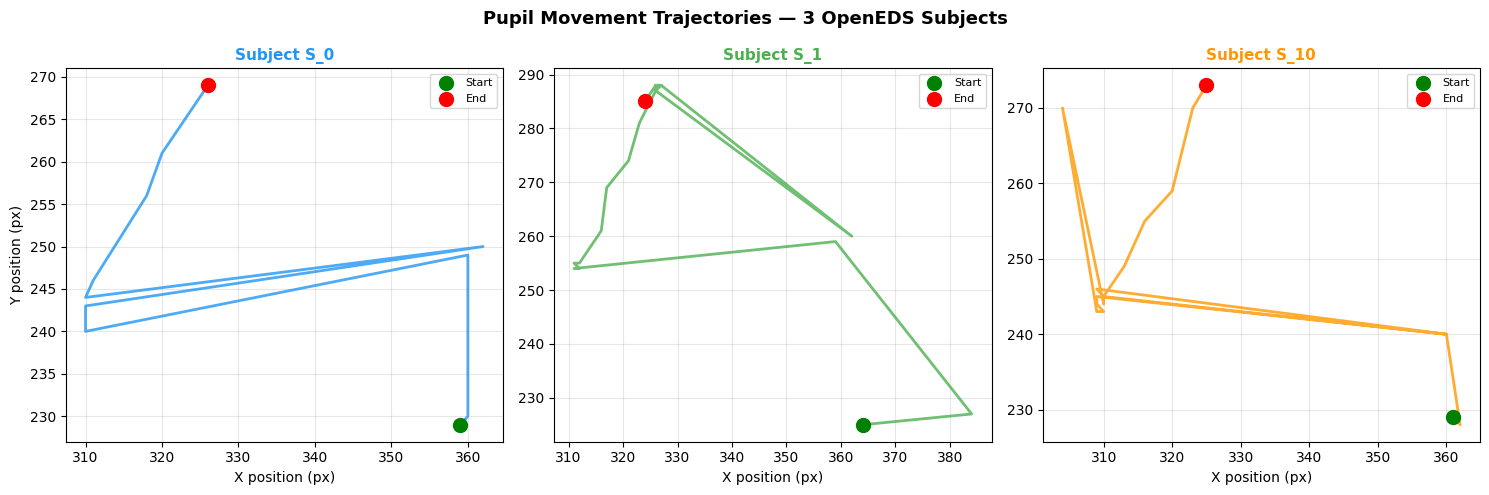

✓ Saved → results/plots/behavioral_pupil_trajectories.png


In [5]:
import cv2

def extract_pupil_center(mask):
    pupil_mask = (mask == 3).astype(np.uint8)
    if pupil_mask.sum() == 0:
        return None
    contours, _ = cv2.findContours(pupil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    M = cv2.moments(largest)
    if M["m00"] > 0:
        return (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"]))
    return None

subjects = sorted([d for d in os.listdir(OPENEDS_PATH)
                   if os.path.isdir(os.path.join(OPENEDS_PATH, d))])[:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pupil Movement Trajectories — 3 OpenEDS Subjects",
             fontsize=13, fontweight='bold')

for idx, (s, color) in enumerate(zip(subjects, COLORS)):
    s_path    = os.path.join(OPENEDS_PATH, s)
    imgs_all  = sorted([f for f in os.listdir(s_path) if f.endswith(".png")])[:20]
    masks_all = sorted([f for f in os.listdir(s_path) if f.endswith(".npy")])[:20]

    cx_list, cy_list = [], []
    for img_f, mask_f in zip(imgs_all, masks_all):
        mask = np.load(os.path.join(s_path, mask_f))
        center = extract_pupil_center(mask)
        if center:
            cx_list.append(center[0])
            cy_list.append(center[1])

    if cx_list:
        axes[idx].plot(cx_list, cy_list, color=color, linewidth=2, alpha=0.8)
        axes[idx].scatter(cx_list[0],  cy_list[0],  color='green', s=100, zorder=5, label='Start')
        axes[idx].scatter(cx_list[-1], cy_list[-1], color='red',   s=100, zorder=5, label='End')
    axes[idx].set_title(f"Subject {s}", fontsize=11, color=color, fontweight='bold')
    axes[idx].set_xlabel("X position (px)")
    if idx == 0: axes[idx].set_ylabel("Y position (px)")
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/behavioral_pupil_trajectories.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/behavioral_pupil_trajectories.png")

###Combined behavioral dashboard

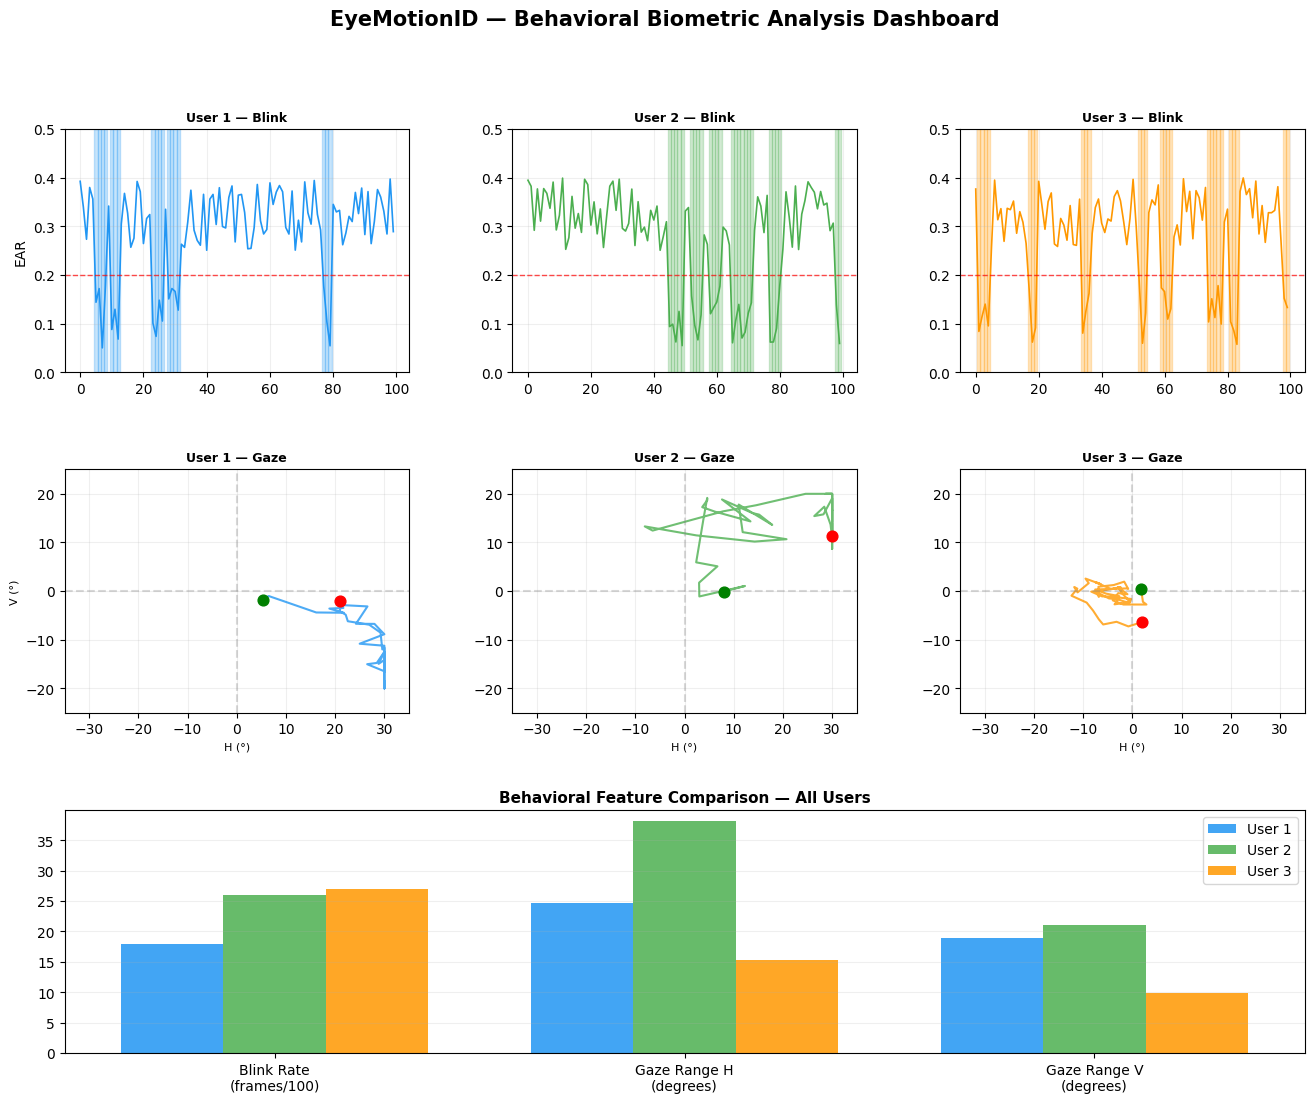

✓ Saved → results/plots/behavioral_dashboard.png


In [6]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("EyeMotionID — Behavioral Biometric Analysis Dashboard",
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Row 1 — Blink timelines
for idx, (user, color) in enumerate(zip(USERS, COLORS)):
    ax = fig.add_subplot(gs[0, idx])
    ear_vals = all_ear_values[idx]
    ax.plot(ear_vals, color=color, linewidth=1.2)
    ax.axhline(y=0.20, color='red', linestyle='--', linewidth=1, alpha=0.7)
    for i, ear in enumerate(ear_vals):
        if ear < 0.20:
            ax.axvspan(i-0.5, i+0.5, alpha=0.25, color=color)
    ax.set_title(f"{user} — Blink", fontsize=9, fontweight='bold')
    ax.set_ylim(0, 0.5)
    ax.set_ylabel("EAR" if idx == 0 else "")
    ax.grid(True, alpha=0.2)

# Row 2 — Gaze paths
for idx, (user, color) in enumerate(zip(USERS, COLORS)):
    ax = fig.add_subplot(gs[1, idx])
    gaze_h, gaze_v = gaze_data[idx]
    ax.plot(gaze_h, gaze_v, color=color, linewidth=1.5, alpha=0.8)
    ax.scatter(gaze_h[0], gaze_v[0], color='green', s=60, zorder=5)
    ax.scatter(gaze_h[-1], gaze_v[-1], color='red', s=60, zorder=5)
    ax.set_xlim(-35, 35)
    ax.set_ylim(-25, 25)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(f"{user} — Gaze", fontsize=9, fontweight='bold')
    ax.set_xlabel("H (°)", fontsize=8)
    ax.set_ylabel("V (°)" if idx == 0 else "", fontsize=8)
    ax.grid(True, alpha=0.2)

# Row 3 — Summary stats
ax_summary = fig.add_subplot(gs[2, :])
categories = ['Blink Rate\n(frames/100)', 'Gaze Range H\n(degrees)', 'Gaze Range V\n(degrees)']
user1_vals = [blink_counts[0], np.ptp(gaze_data[0][0]), np.ptp(gaze_data[0][1])]
user2_vals = [blink_counts[1], np.ptp(gaze_data[1][0]), np.ptp(gaze_data[1][1])]
user3_vals = [blink_counts[2], np.ptp(gaze_data[2][0]), np.ptp(gaze_data[2][1])]

x = np.arange(len(categories))
width = 0.25
ax_summary.bar(x - width, user1_vals, width, label='User 1', color=COLORS[0], alpha=0.85)
ax_summary.bar(x,         user2_vals, width, label='User 2', color=COLORS[1], alpha=0.85)
ax_summary.bar(x + width, user3_vals, width, label='User 3', color=COLORS[2], alpha=0.85)
ax_summary.set_xticks(x)
ax_summary.set_xticklabels(categories, fontsize=10)
ax_summary.set_title("Behavioral Feature Comparison — All Users", fontsize=11, fontweight='bold')
ax_summary.legend(fontsize=10)
ax_summary.grid(True, alpha=0.2, axis='y')

plt.savefig(f"{PLOTS}/behavioral_dashboard.png", dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved → results/plots/behavioral_dashboard.png")

###Summary

In [7]:
print("=" * 50)
print("   DAY 13 — BEHAVIORAL VISUALIZATIONS SUMMARY")
print("=" * 50)
print()
print("Visualizations created:")
print("  ✓ Blink timeline — 3 users compared")
print("  ✓ Blink frequency bar chart")
print("  ✓ Gaze movement paths — 3 users")
print("  ✓ Pupil movement trajectories — OpenEDS")
print("  ✓ Combined behavioral dashboard")
print()
print("Plots saved → results/plots/")
print("  ✓ behavioral_blink_timeline.png")
print("  ✓ behavioral_blink_frequency.png")
print("  ✓ behavioral_gaze_paths.png")
print("  ✓ behavioral_pupil_trajectories.png")
print("  ✓ behavioral_dashboard.png")
print()
print("Week 2 deliverables — ALL COMPLETE:")
print("  ✓ Eye preprocessing pipeline")
print("  ✓ Blink detection system")
print("  ✓ Gaze and pupil tracking module")
print("  ✓ Prepared behavioral eye dataset")
print()
print("Next → Day 14: Week 2 Review + GitHub upload")
print("=" * 50)

   DAY 13 — BEHAVIORAL VISUALIZATIONS SUMMARY

Visualizations created:
  ✓ Blink timeline — 3 users compared
  ✓ Blink frequency bar chart
  ✓ Gaze movement paths — 3 users
  ✓ Pupil movement trajectories — OpenEDS
  ✓ Combined behavioral dashboard

Plots saved → results/plots/
  ✓ behavioral_blink_timeline.png
  ✓ behavioral_blink_frequency.png
  ✓ behavioral_gaze_paths.png
  ✓ behavioral_pupil_trajectories.png
  ✓ behavioral_dashboard.png

Week 2 deliverables — ALL COMPLETE:
  ✓ Eye preprocessing pipeline
  ✓ Blink detection system
  ✓ Gaze and pupil tracking module
  ✓ Prepared behavioral eye dataset

Next → Day 14: Week 2 Review + GitHub upload
